In [52]:
# Problem Statement: The anomalies in data that record a poorly maintained ship's engine functions require a focus on pressure (oil, coolant, fuel) and temperature (coolant, oil). The visualization of the data

In [70]:
# 1. Import the required libraries and data set with the provided URL.
# Import the necessary libraries.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from scipy.stats import pearsonr, spearmanr
from scipy.stats import zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
from random import random

In [ ]:
# URL to import data set from GitHub.

url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

# Read the CSV file into a new DataFrame.
df = pd.read_csv(url)

# Display the first few rows of the DataFrame.
print(df.shape)
df.head()

(19535, 6)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [ ]:
#2. Identify missing or duplicate values.

df.info()
df.isnull().sum()
df.duplicated().sum()
# data info indicates that there are no non-null values and no duplicAtE VALUES

df['Coolant pressure'].isnull()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB


,Coolant pressure
0,False
1,False
2,False
3,False
4,False
...,...
19530,False
19531,False
19532,False
19533,False


In [ ]:
# All columns are numeric values, all float measurements (i.e. continuous numeric) with the exception of engine rpm, which is integer
# Make engine rpm into a float because it means data could be easier to work with and is less likely to result in errors or limit statistical test opportunities

# Convert the 'integers' column to float
df['Engine rpm'] = df['Engine rpm'].astype(float)

print(df.dtypes)

# additional changes to the data types is unecessary because ML algorithms can work with numeric data of one type

Engine rpm          float64
Lub oil pressure    float64
Fuel pressure       float64
Coolant pressure    float64
lub oil temp        float64
Coolant temp        float64
dtype: object


In [ ]:
# Assuming 'df' is your DataFrame
# Replace with the actual names of your six columns
columns_to_count = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']

for column in columns_to_count:
    min_value = df.min()
    max_value = df.max()

print(f"Minimum values in each:\n{min_value}")
print(f"Maximum values in each column:\n{max_value}") # REMOVE OUTLIERS AND RUN CODE CELL AGAIN


Minimum values in each:
Engine rpm          61.000000
Lub oil pressure     0.003384
Fuel pressure        0.003187
Coolant pressure     0.002483
lub oil temp        71.321974
Coolant temp        61.673325
dtype: float64
Maximum values in each column:
Engine rpm          2239.000000
Lub oil pressure       7.265566
Fuel pressure         21.138326
Coolant pressure       7.478505
lub oil temp          89.580796
Coolant temp         195.527912
dtype: float64


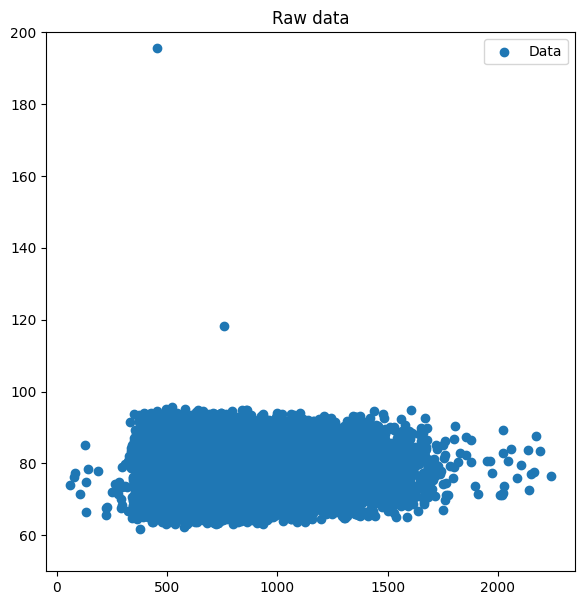

In [ ]:
# Does the data suggest that there is an engine related fault?
# Evidence for the Problem Statement

#2. View the DataFrame and perform EDA, including identifying missing or duplicate values.

# Plot the results.
plt.figure(figsize=(15, 7))

# Plot the raw data with outliers.
plt.subplot(1, 2, 1)
plt.scatter(df['Engine rpm'], df['Coolant temp'], label='Data')
plt.ylim(50, 200)  # Fix the y-axis scale.
plt.title('Raw data')
plt.legend()

# use the method implemented for number of children with bmi.
# Was the Coolant pressure valve shut-off during a stationary period/waiting/anchoring that resulted in this larger than normal data point, which impeded the circulatory function of the coolant and subsequently saw it evaporate and attain these high temperatures? Does the use of the pressure in the coolant instantaneously allow the gaseous exchange to dissapate through an exit channel? Has this occurred much in the past? Is it a design. fault that is simply unavoidable to achieve the higher levels of performance required by the navigator and captain

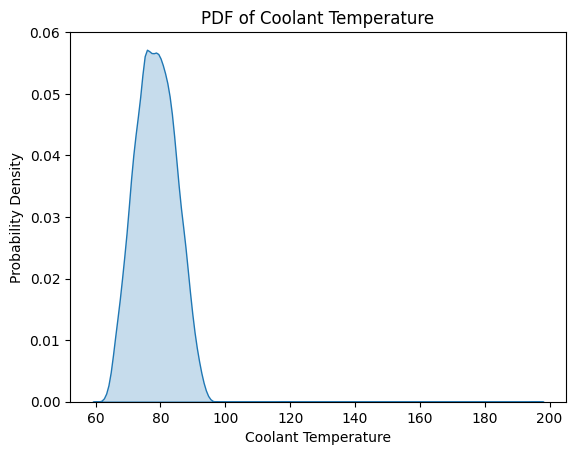

In [ ]:
sns.kdeplot(df['Coolant temp'], fill=True)
plt.xlabel('Coolant Temperature')
plt.ylabel('Probability Density')
plt.title('PDF of Coolant Temperature')
plt.show()

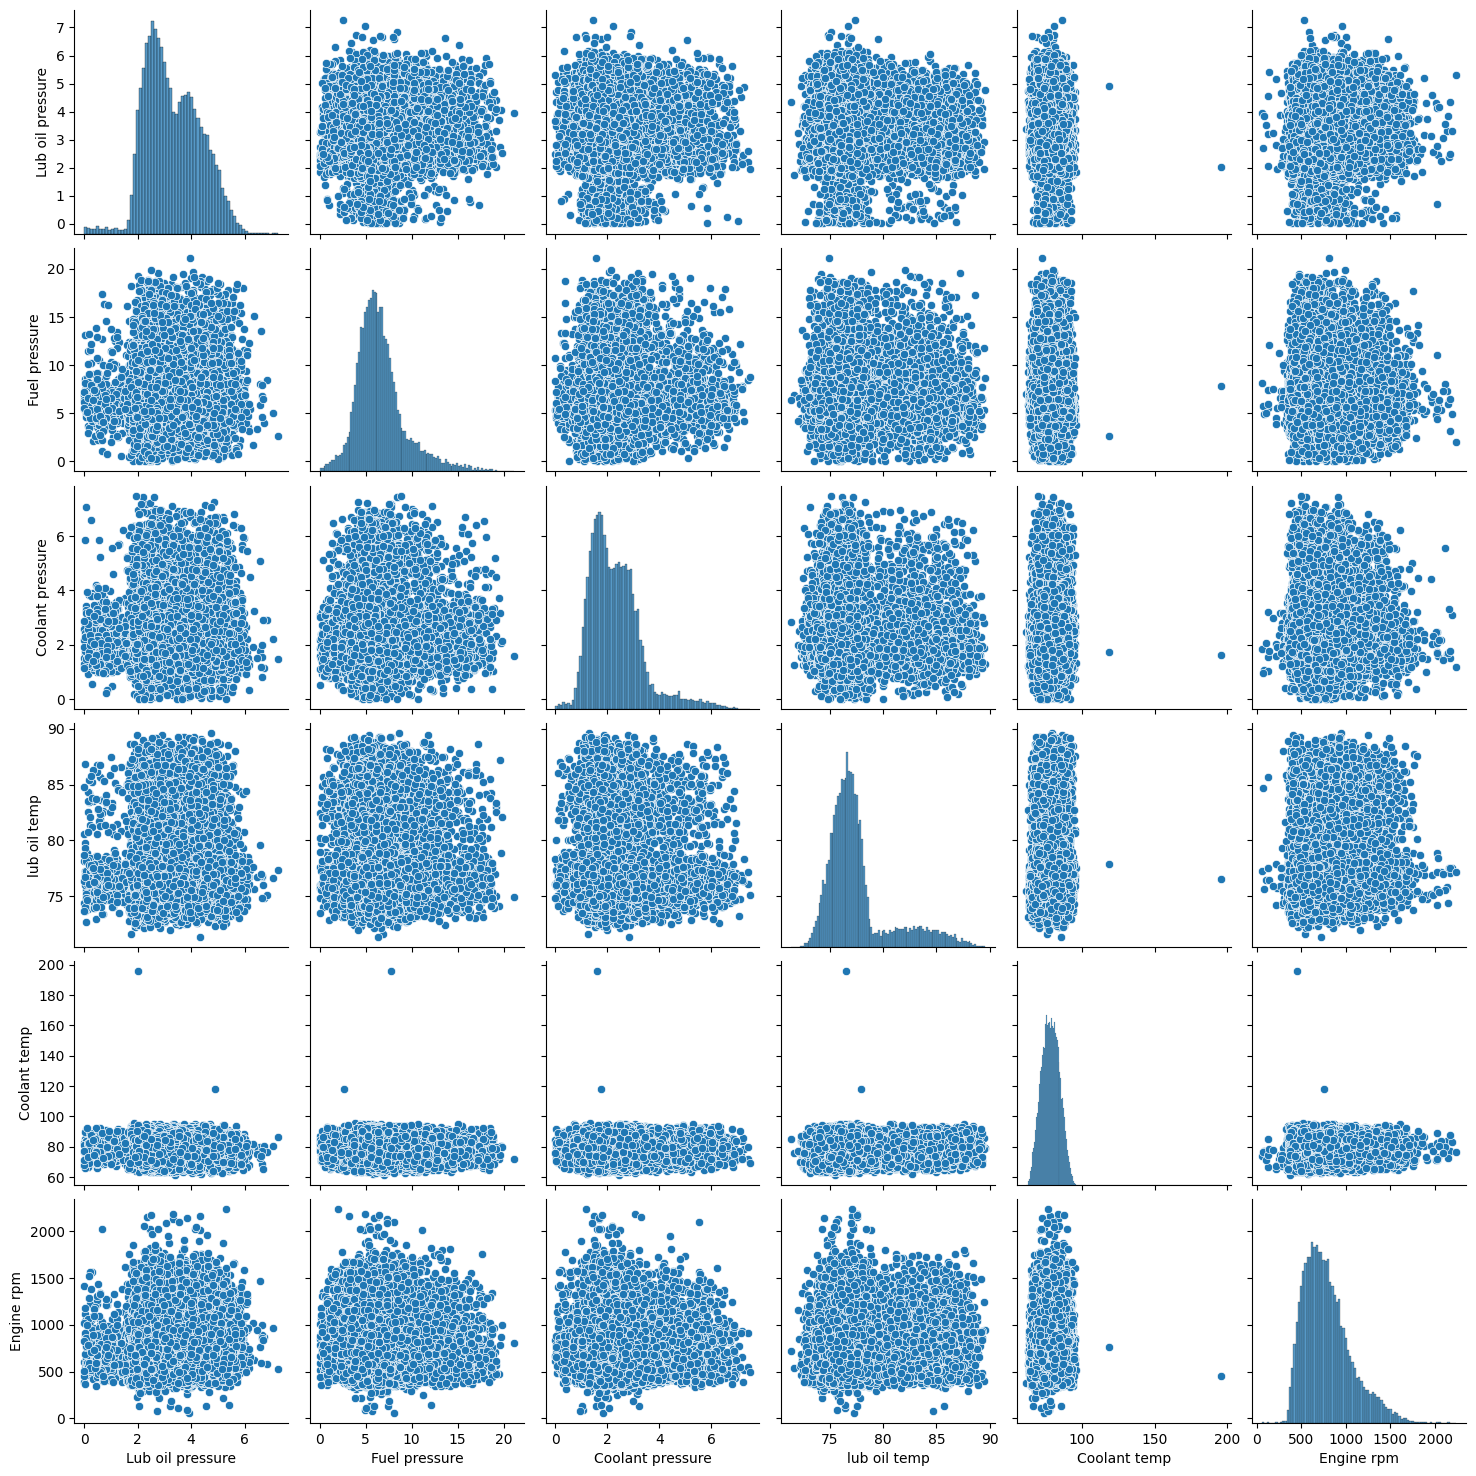

In [ ]:
# Visualization of the data in order to explore the wide variety of features [add all feature exploration plots here
sns.pairplot(df[['Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp', 'Engine rpm']])
plt.show()
# Coolant temperature does not fall below 50 degrees and is negatively impacting the performance of the other four independent variables . Lub oil temp begins at approx 70 degrees. Coolant pressure is indiscriminantly high whether lub oil temp is high or low and this means that the coolant is having an adverse effect and it is essentially increasing in temperature - coolant pressure is high as a consequence of excessively high temperatures in both lubricating oil and coolant. Is there a leak in the lub oil transmission system? Has the excessively high oil temperatures burnt a hole in a pipe

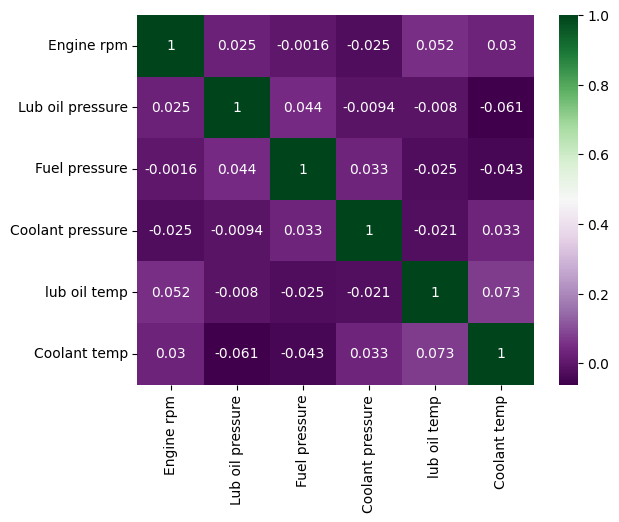

In [ ]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='PRGn')
plt.show()

# A perfect positive linear correlation between Coolant temperature and Engine rpm. This means that the engine is working very hard when coolant requirement increases. However, the plot above shows that the coolant is reaching very high temperatures, contrary to its function, and affecting the effort used to power the engine. The lub oil temp is being driven up to unsafe levels and the effort expended by the coolant, fuel and lubricant oil pressures combined. The pressure systems combined could be forcing the lubricant and coolant temperatures to reach high temperatures. Hypothesis 0: The temperature of lubricant oil is driven-up by the lub oil pressure hypothesis 1: it is not.

# Use of PRGn in order to emphasize a difference at the mid-point of the data

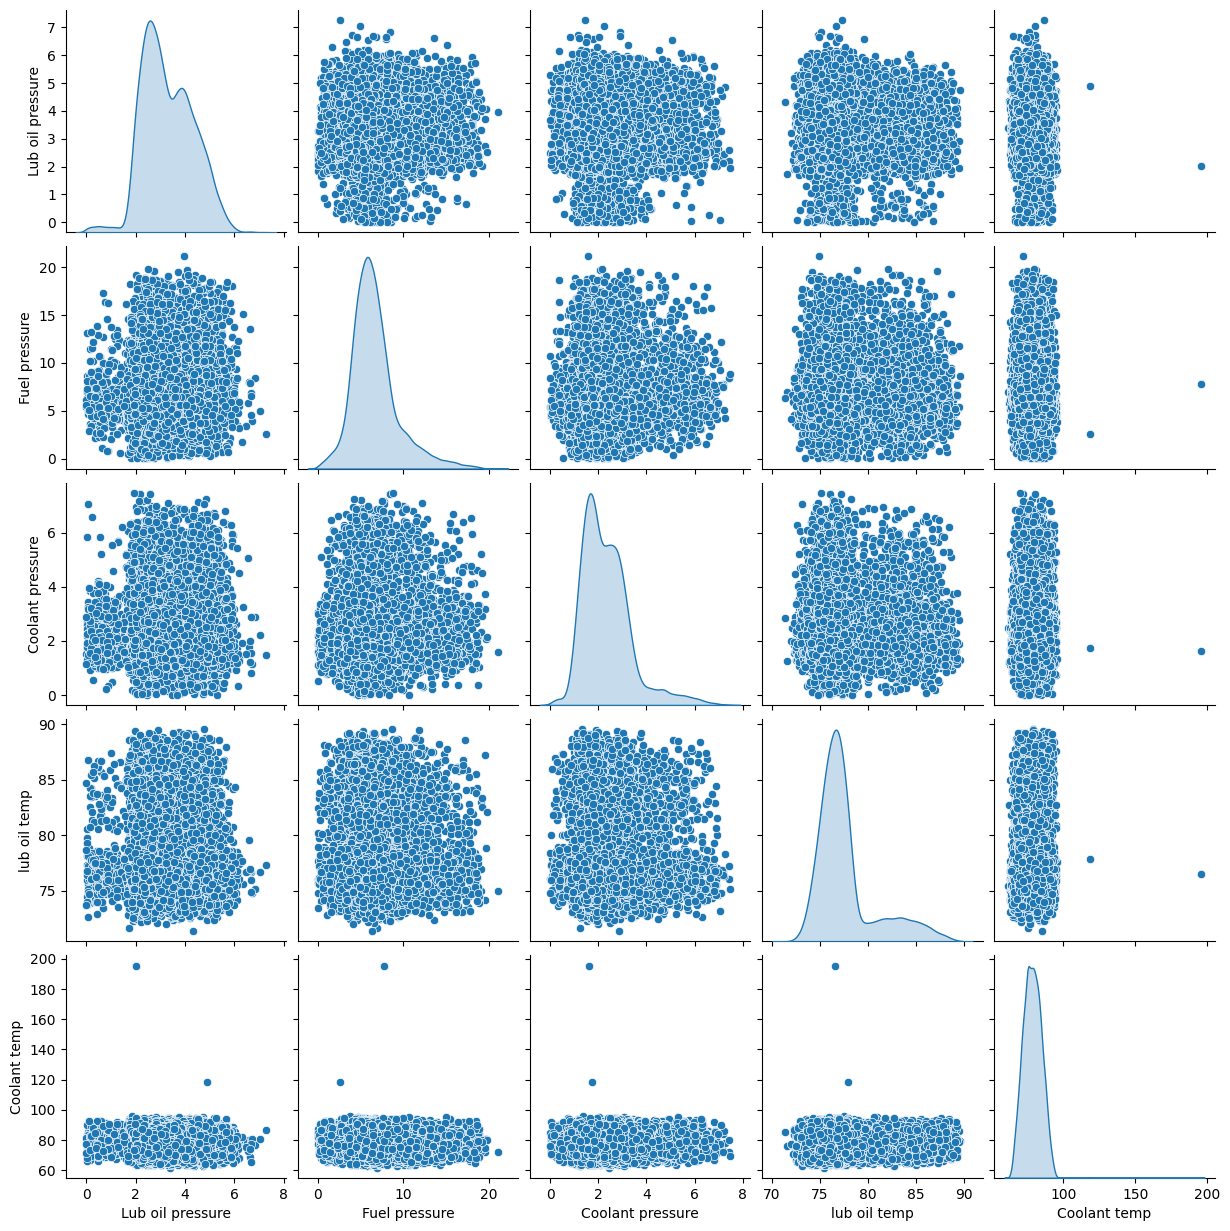

In [ ]:
# Create the pairplot with kde on the diagonal
sns.pairplot(df[['Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']], diag_kind='kde')

plt.show()

# Bin the data into 20 bins -- df_bins = df.apply(lambda x: pd.cut(x, bins=10000, labels=False, include_lowest=True))
# Create the pairplot with binned data - sns.pairplot(df_bins, diag_kind='hist')

<Figure size 1200x800 with 0 Axes>

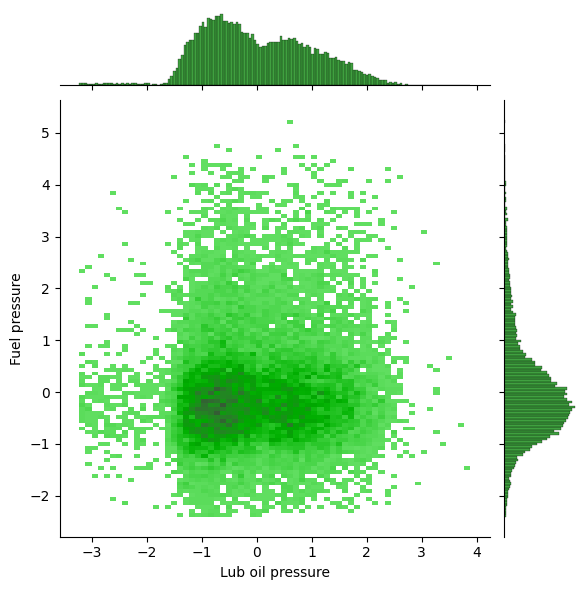

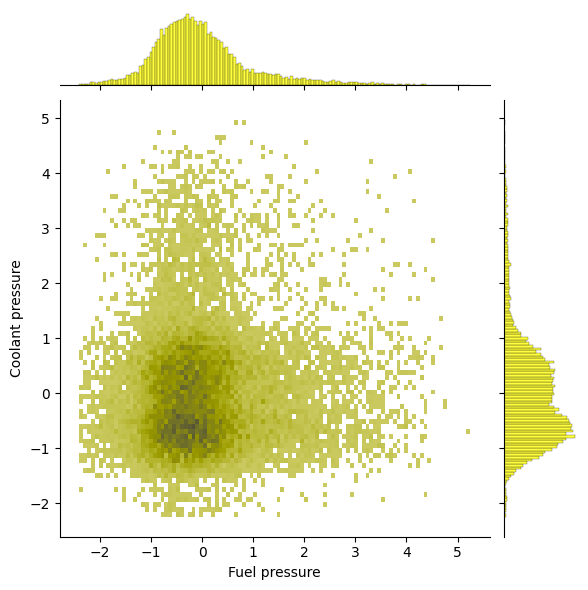

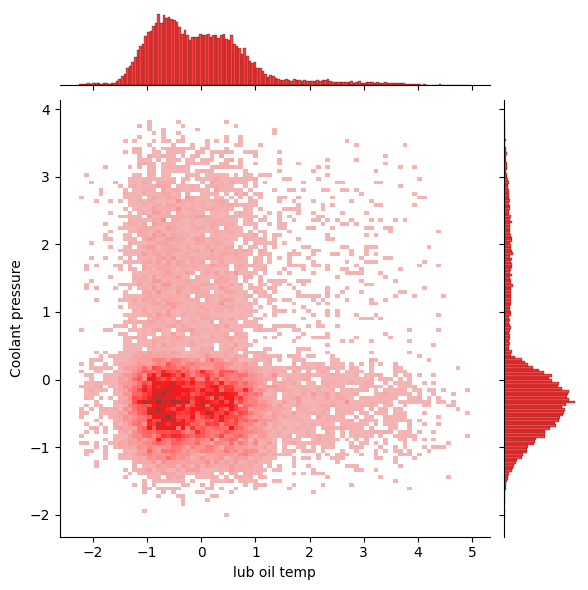

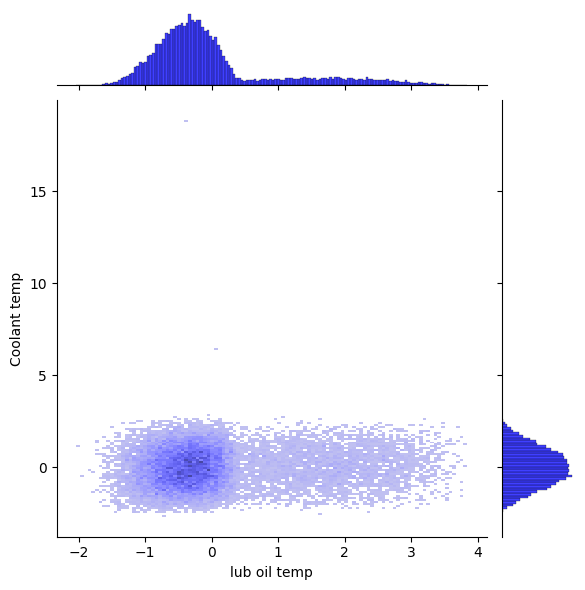

In [ ]:
df_norm = df.copy()

scaler = StandardScaler()

df_norm[['Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']] = scaler.fit_transform(df_norm[['Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']])

plt.figure(figsize=(12, 8))

j = sns.jointplot(x='Lub oil pressure', y='Fuel pressure', data=df_norm, kind='hist', marginal_kws=dict(bins=150), color='green')
j.set_axis_labels('Lub oil pressure', 'Fuel pressure')
plt.show()

k = sns.jointplot(x='Fuel pressure', y='Coolant pressure', data=df_norm, kind='hist', marginal_kws=dict(bins=150), color='yellow')
k.set_axis_labels('Fuel pressure', 'Coolant pressure')
plt.show()

l = sns.jointplot(x='Coolant pressure', y='lub oil temp', data=df_norm, kind='hist', marginal_kws=dict(bins=150), color='red')
l.set_axis_labels('lub oil temp', 'Coolant pressure')
plt.show()

df_clean_ct = df_norm.copy(['Coolant temp'])

scaled_ct = StandardScaler()
ct_outl =  df_clean_ct.copy()
ct_outl[['Coolant temp']] = scaled_ct.fit_transform(ct_outl[['Coolant temp']])
ct_outl.head()

m = sns.jointplot(x='lub oil temp', y='Coolant temp', data=df_norm, kind='hist', marginal_kws=dict(bins=150), color='blue')
m.set_axis_labels('lub oil temp', 'Coolant temp')
plt.show() # Coolant temp loses two values during the normalization process - should two median values be added to the dataset?
# Coolant temperature is normally distributed around the mean for lubricant oil temperature, which is right skewed for cool pressure but coolant pressure is bi-peaked, the second of which is over the mean. -0.6 to 0.4 approximately is the range of lub oil temp to coolant pressure, coolant pressure has strong right skew with a long left-tailed distribution. Coolant pressure peaks highest at -1.0 to fuel pressure, approximately -0.4, with strong density in the negative to negative -1 and moderate upto 1 for coolant pressure. Fuel pressure is distributed around the -0.5 approximately to lub oil pressure, which has two peaks (approx -0.8 and approx 0.5).


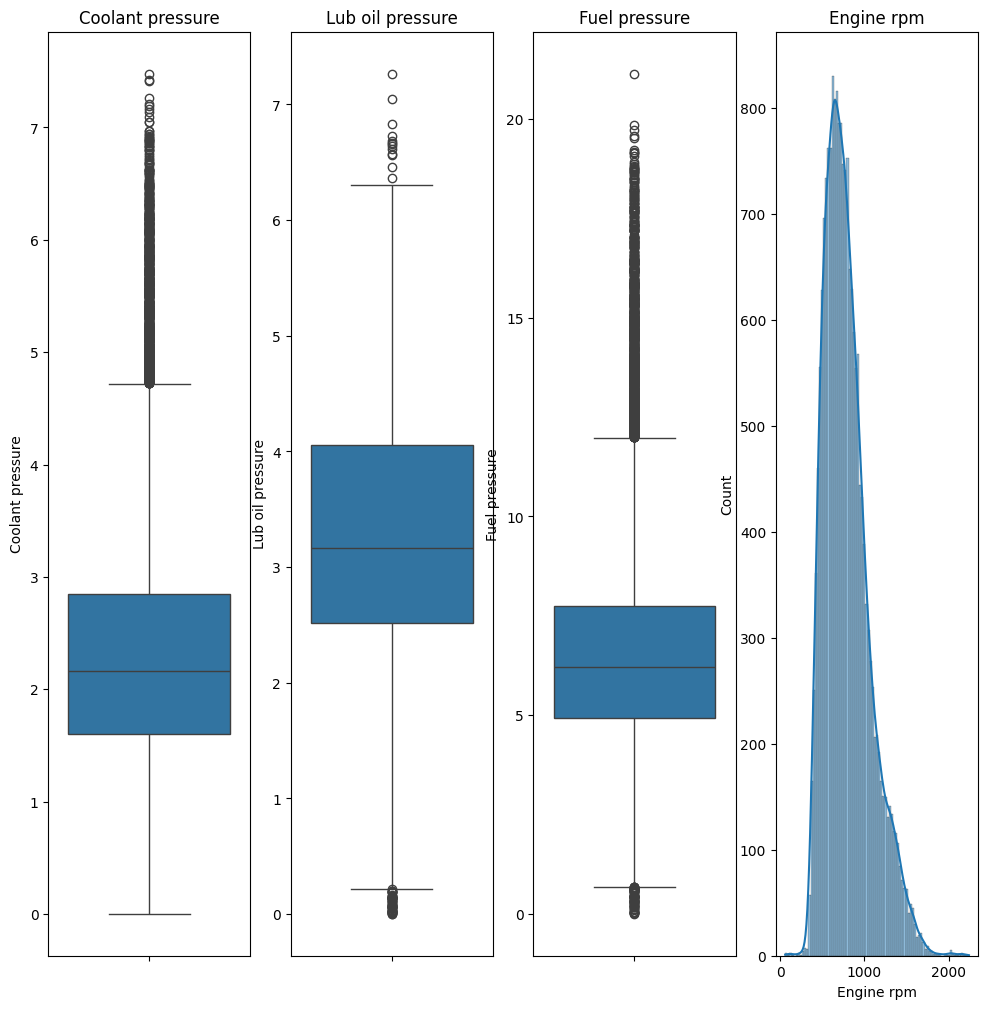

In [ ]:
# step 2, Explore the data set to understand the features
# find optimum number of features/columns and justify your assumption(s

# Visualise engine data with histogram.
plt.figure(figsize=(12, 12))

# Plot the raw data with outliers.
plt.subplot(1, 4, 1)
sns.boxplot(data = df['Coolant pressure'])
plt.title('Coolant pressure')

plt.subplot(1, 4, 2)
sns.boxplot(data = df['Lub oil pressure'])
plt.title('Lub oil pressure')

plt.subplot(1, 4, 3)
sns.boxplot(data = df['Fuel pressure'])
plt.title('Fuel pressure')

plt.subplot(1, 4, 4)
sns.histplot(data = df['Engine rpm'], kde = True)
plt.title('Engine rpm')

plt.show()

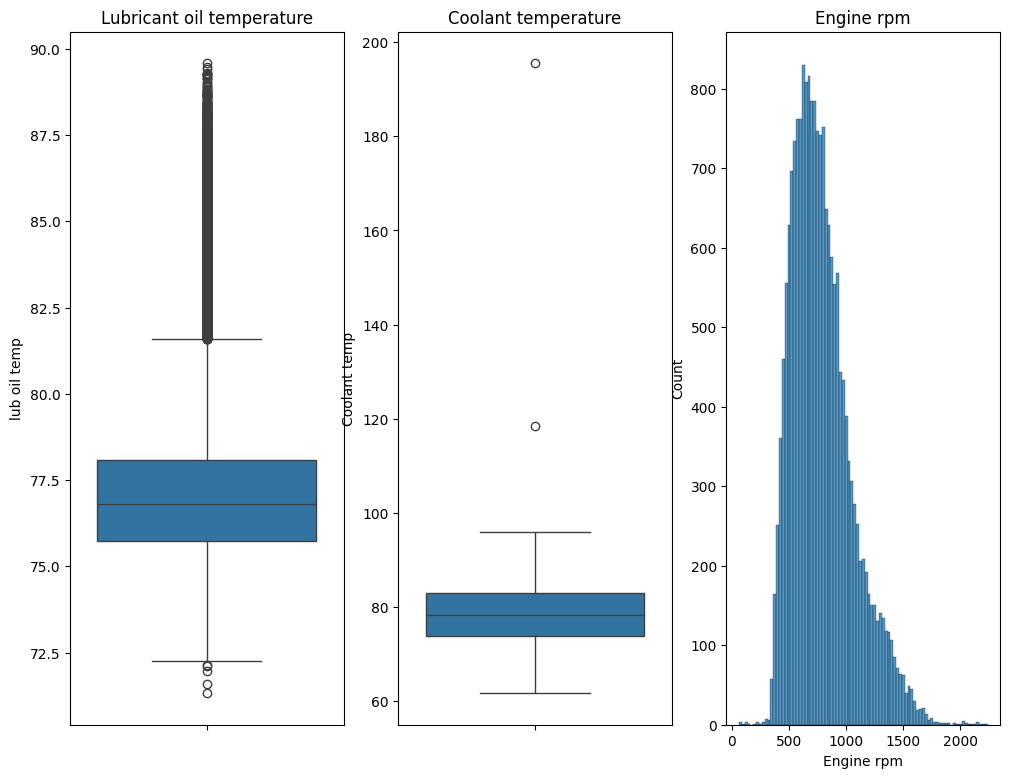

<Figure size 640x480 with 0 Axes>

In [ ]:
# Visualise engine data with histogram.
plt.figure(figsize=(12, 9))

# Plot the raw data with outliers.
plt.subplot(1, 3, 1)
sns.boxplot(data = df['lub oil temp'])
plt.title('Lubricant oil temperature')

plt.subplot(1, 3, 2)
sns.boxplot(data = df['Coolant temp'])
plt.title('Coolant temperature')

plt.subplot(1, 3, 3)
sns.histplot(data = df['Engine rpm'])
plt.title('Engine rpm')
plt.show()

plt.tight_layout()

# Has only the data that tracks the engine failure been supplied?
# It seems that lub oil temp has been extremely high since the engine was turned on.

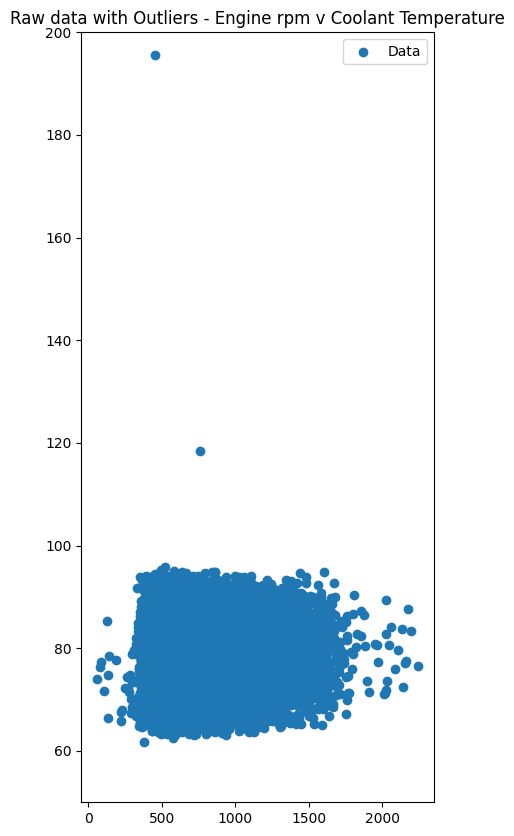

In [ ]:
#2. View the DataFrame and perform EDA, i

# Plot the results.
plt.figure(figsize=(10, 10))

# Plot the raw data with outliers.
plt.subplot(1, 2, 1)
plt.scatter(df['Engine rpm'], df['Coolant temp'], label='Data')
plt.ylim(50, 200)  # Fix the y-axis scale.
plt.title('Raw data with Outliers - Engine rpm v Coolant Temperature')
plt.legend()

# use the method implemented for number of children with bmi.
# Was the Coolant pressure valve shut-off during a stationary period/waiting/anchoring that resulted in this larger than normal data point, which impeded the circulatory function of the coolant and subsequently saw it evaporate and attain these high temperatures? Does the use of the pressure in the coolant instantaneously allow the gaseous exchange to dissapate through an exit channel? Has this occurred much in the past? Is it a design. fault that is simply unavoidable to achieve the higher levels of performance required by the navigator and captain

3. Descriptive Statistics

In [ ]:
#3. Generate the descriptive statistics of the data, including:
#observing the mean for each feature
df.describe()

# Plot the IQR anomaly detection

# Assumptions (i) at low engine rpm, there is too little lubricant used - friction and over-heating are probable consequences. Regardless, the engine is often running more than 14* the minimum (ii) Immense variation in fuel pressure.The low level is detrimental to the fuel pump system and fuel consumption efficincies, which is also a problem for emissions. The higher-level suggests fuel or pump issues because there are inefficiencies in its use (iii) Head gaskets might be failing when the coolant pressure is high but it is difficult to know because it leads to overheating, as does a low level, when there are problems with leaks or filtration (iv) degredation of the engine is indicated by higher temp because the properties of the oil cannot perform adequately at excessive temperatures, although inadequacy is also shown by lower temperatures. (v)

# The problem statement is that the extreme lub oil temp is > 3 std dev above the base temp at 75% mark and the same issue is causing a similair disturbance in the coolant pressure - resulting in an exponentially high maximum coolant temperature. The engine is thus forced to work excessively hard. Whatever is causing the error effects all features at the upper extremes. Fuel pressure, at the maximum echelon, is particularly high.

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


In [ ]:
#3. Generate the descriptive statistics of the data, including:
#identifying the median
df.median()
print(df.median())

df.isnull().sum()
print(df.isnull().sum())

Engine rpm          746.000000
Lub oil pressure      3.162035
Fuel pressure         6.201720
Coolant pressure      2.166883
lub oil temp         76.817350
Coolant temp         78.346662
dtype: float64
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64


3. IQR Values and Plots

In [ ]:
#3. Generate the descriptive statistics of the data, including:
#idenitfying the range values beyond the 95th percentile for at least two features.
# Calculate the 0.95 quantile
df.quantile(0.95)
print(df.quantile(0.95))

# Create a variable for 0.95 quantile
_95 = df.quantile(0.95)

# Calculate the range above the 0.95 quantile
greater_than_95 = df[df > _95].max() - _95

# Print the result
print(f'Greater than 95% quantile:', greater_than_95)

Engine rpm          1324.000000
Lub oil pressure       5.058040
Fuel pressure         12.208475
Coolant pressure       4.438415
lub oil temp          84.940778
Coolant temp          88.612891
Name: 0.95, dtype: float64
Greater than 95% quantile: Engine rpm          915.000000
Lub oil pressure      2.207526
Fuel pressure         8.929851
Coolant pressure      3.040090
lub oil temp          4.640018
Coolant temp        106.915021
dtype: float64


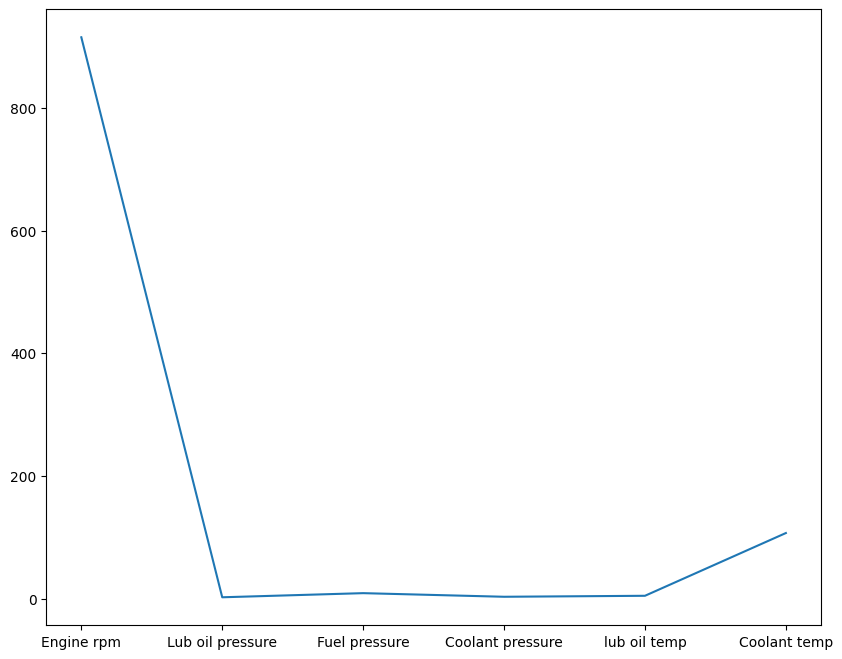

In [ ]:
# Plot the results.
plt.figure(figsize=(10, 8))
plt.plot(greater_than_95)
plt.show()


Range of values beyond the 95th percentile for at least two features.
df.quantile(0.95

In [ ]:
# Use the IQR method to identify the outliers.
Q1 = df['Coolant temp'].quantile(0.25)
Q3 = df['Coolant temp'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove the outliers.
df_clean_ct = df[(df['Coolant temp'] > lower_bound) & (df['Coolant temp'] < upper_bound)]
df_clean_ct

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682.0,2.391656,4.617196,2.848982,76.272417,69.884609
1,605.0,5.466877,6.424361,5.727520,73.222679,74.907314
2,658.0,3.434232,3.680896,1.678708,88.089916,78.704806
3,749.0,2.094656,7.120927,1.639670,77.661625,82.386700
4,676.0,3.538228,5.956472,3.225336,75.226352,67.153220
...,...,...,...,...,...,...
19530,681.0,3.598792,7.300853,1.083391,76.206955,69.848780
19531,580.0,2.243040,5.242489,1.471350,76.884907,87.098119
19532,616.0,3.310048,3.787693,6.001031,75.889810,72.220009
19533,1163.0,2.731726,3.703595,2.951684,76.784626,81.400088


In [ ]:
# Coolant indicates the greatest abnormality in results, followed by fuel pressure
# Use the IQR method to identify the outliers.
Q1 = df['Fuel pressure'].quantile(0.25)
Q3 = df['Fuel pressure'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove the outliers.
df_clean_fp = df[(df['Fuel pressure'] > lower_bound) & (df['Fuel pressure'] < upper_bound)]
df_clean_fp

# Fuel pressure has an almost normal distribution (which kernel smoothing might clarify)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682.0,2.391656,4.617196,2.848982,76.272417,69.884609
1,605.0,5.466877,6.424361,5.727520,73.222679,74.907314
2,658.0,3.434232,3.680896,1.678708,88.089916,78.704806
3,749.0,2.094656,7.120927,1.639670,77.661625,82.386700
4,676.0,3.538228,5.956472,3.225336,75.226352,67.153220
...,...,...,...,...,...,...
19530,681.0,3.598792,7.300853,1.083391,76.206955,69.848780
19531,580.0,2.243040,5.242489,1.471350,76.884907,87.098119
19532,616.0,3.310048,3.787693,6.001031,75.889810,72.220009
19533,1163.0,2.731726,3.703595,2.951684,76.784626,81.400088


In [ ]:
def clean_and_calculate_iqr(df, column):
  """
  Cleans outliers from a specified column in a DataFrame using IQR and prints IQR values.

  Args:
    df: DataFrame containing the data.
    column: Name of the column to clean.

  Returns:
    A new DataFrame with outliers removed from the specified column.
  """
  df_clean = df.copy()
  Q1 = df_clean[column].quantile(0.25)
  Q3 = df_clean[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]
  print(f"IQR for {column}: {IQR}")
  print(f"Lower bound for {column}: {lower_bound}")
  print(f"Upper bound for {column}: {upper_bound}")
  return df_clean

# Use the defined function to calculate iteratively the IQR of columns_to_clean:
columns_to_clean = ['Coolant temp', 'Lub oil pressure', 'Fuel pressure', 'lub oil temp', 'Coolant pressure', 'Engine rpm']
cleaned_dfs = {}
for column in columns_to_clean:
    cleaned_df_name = f"df_clean_{column.replace(' ', '_').lower()}"
    cleaned_dfs[cleaned_df_name] = clean_and_calculate_iqr(df, column)

IQR for Coolant temp: 9.019990405000001
Lower bound for Coolant temp: 60.3654353225
Upper bound for Coolant temp: 96.4453969425
IQR for Lub oil pressure: 1.5364568035000001
Lower bound for Lub oil pressure: 0.21412951074999942
Upper bound for Lub oil pressure: 6.35995672475
IQR for Fuel pressure: 2.8280872365
Lower bound for Fuel pressure: 0.6747552422499998
Upper bound for Fuel pressure: 11.987104188250001
IQR for lub oil temp: 2.3457003349999894
Lower bound for lub oil temp: 72.20743972750003
Upper bound for lub oil temp: 81.59024106749999
IQR for Coolant pressure: 1.2483737979999998
Lower bound for Coolant pressure: -0.27209483399999956
Upper bound for Coolant pressure: 4.7214003579999995
IQR for Engine rpm: 341.0
Lower bound for Engine rpm: 81.5
Upper bound for Engine rpm: 1445.5


In [ ]:
# Clean each column and store the results in separate DataFrames
df_clean_lop = clean_and_calculate_iqr(df, 'Lub oil pressure')
df_clean_fp = clean_and_calculate_iqr(df, 'Fuel pressure')
df_clean_cp = clean_and_calculate_iqr(df, 'Coolant pressure')
df_clean_lot = clean_and_calculate_iqr(df, 'lub oil temp')
df_clean_ct = clean_and_calculate_iqr(df, 'Coolant temp')
df_clean_erpm = clean_and_calculate_iqr(df, 'Engine rpm')



IQR for Lub oil pressure: 1.5364568035000001
Lower bound for Lub oil pressure: 0.21412951074999942
Upper bound for Lub oil pressure: 6.35995672475
IQR for Fuel pressure: 2.8280872365
Lower bound for Fuel pressure: 0.6747552422499998
Upper bound for Fuel pressure: 11.987104188250001
IQR for Coolant pressure: 1.2483737979999998
Lower bound for Coolant pressure: -0.27209483399999956
Upper bound for Coolant pressure: 4.7214003579999995
IQR for lub oil temp: 2.3457003349999894
Lower bound for lub oil temp: 72.20743972750003
Upper bound for lub oil temp: 81.59024106749999
IQR for Coolant temp: 9.019990405000001
Lower bound for Coolant temp: 60.3654353225
Upper bound for Coolant temp: 96.4453969425
IQR for Engine rpm: 341.0
Lower bound for Engine rpm: 81.5
Upper bound for Engine rpm: 1445.5


IQR for Coolant temp: 9.019990405000001
Lower bound for Coolant temp: 60.3654353225
Upper bound for Coolant temp: 96.4453969425
IQR for Lub oil pressure: 1.5364568035000001
Lower bound for Lub oil pressure: 0.21412951074999942
Upper bound for Lub oil pressure: 6.35995672475
IQR for Fuel pressure: 2.8280872365
Lower bound for Fuel pressure: 0.6747552422499998
Upper bound for Fuel pressure: 11.987104188250001
IQR for lub oil temp: 2.3457003349999894
Lower bound for lub oil temp: 72.20743972750003
Upper bound for lub oil temp: 81.59024106749999
IQR for Coolant pressure: 1.2483737979999998
Lower bound for Coolant pressure: -0.27209483399999956
Upper bound for Coolant pressure: 4.7214003579999995
IQR for Engine rpm: 341.0
Lower bound for Engine rpm: 81.5
Upper bound for Engine rpm: 1445.5


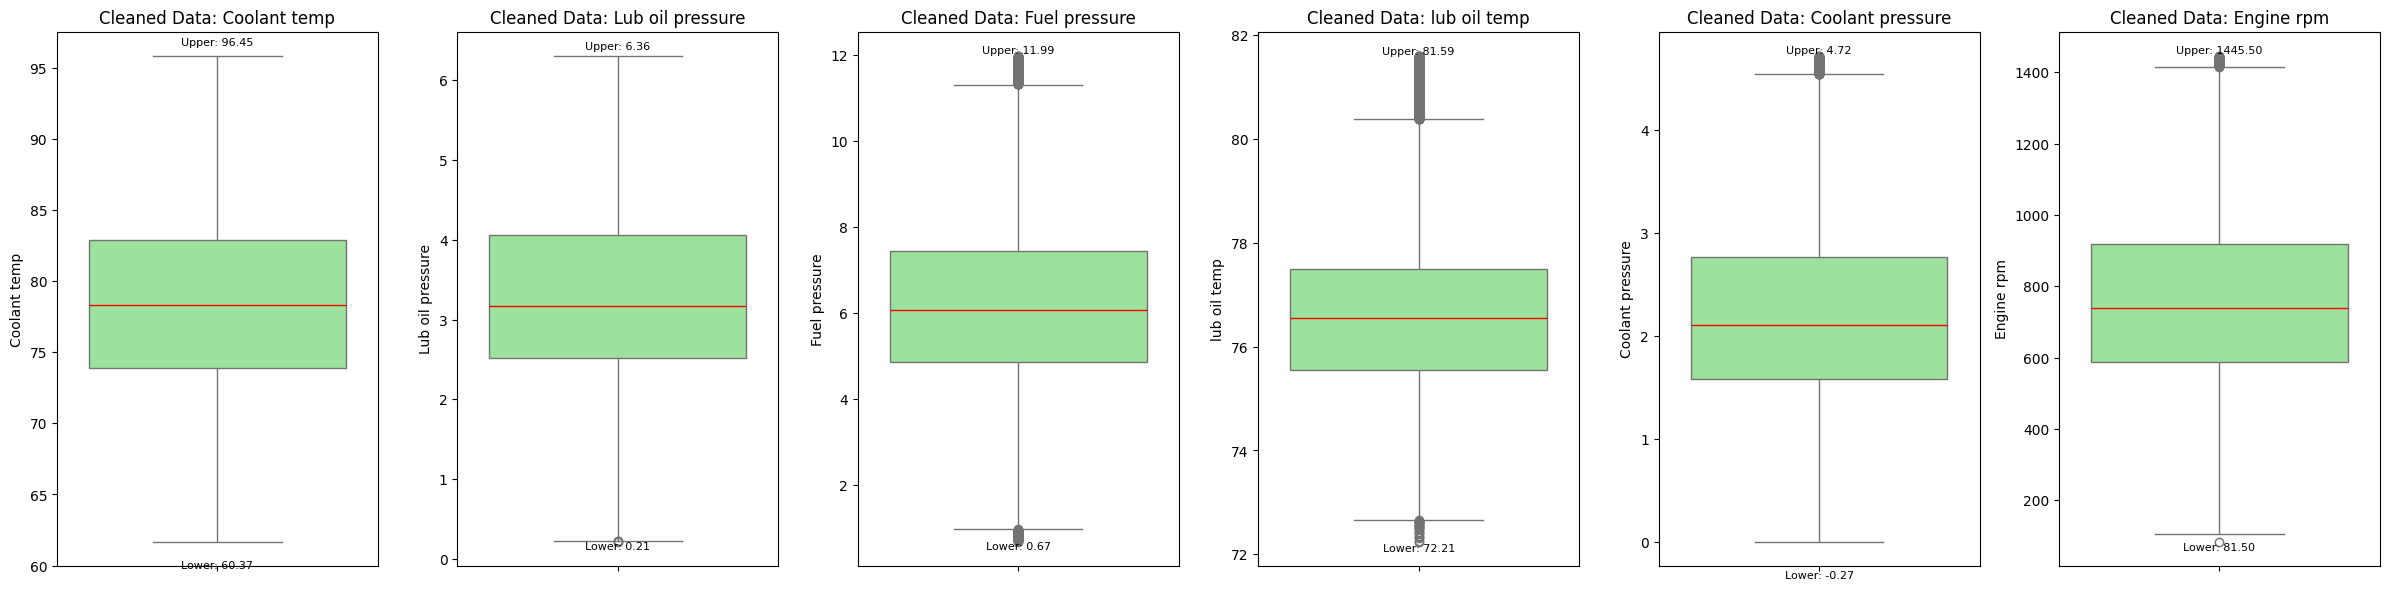

In [ ]:
def clean_and_calculate_iqr(df, column):
  """
  Cleans outliers from specified columns using IQR and IQR values.

  Args:
    df: DataFrame containing the data.
    column: Name of the column to clean.

  Returns:
    A new DataFrame with outliers removed from the specified column, IQR, lower bound, and upper bound.
  """
  df_clean = df.copy()
  Q1 = df_clean[column].quantile(0.25)
  Q3 = df_clean[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]
  print(f"IQR for {column}: {IQR}")
  print(f"Lower bound for {column}: {lower_bound}")
  print(f"Upper bound for {column}: {upper_bound}")
  return df_clean, IQR, lower_bound, upper_bound  # Return cleaned DataFrame and IQR values

def plot_boxplots(df, cleaned_dfs, columns_to_plot):
  """
  Plots boxplots for cleaned data for multiple columns in a single row,
  labeling upper and lower bounds.

  Args:
    df: DataFrame containing the original data.
    cleaned_dfs: Dictionary of cleaned DataFrames.
    columns_to_plot: List of column names to plot.
  """

  num_cols = len(columns_to_plot)
  fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 6))

  for i, column in enumerate(columns_to_plot):
    cleaned_df, IQR, lower_bound, upper_bound = cleaned_dfs[f"df_clean_{column.replace(' ', '_').lower()}"]
    sns.boxplot(y=cleaned_df[column], ax=axes[i], color='lightgreen', medianprops={'color': 'red'})
    axes[i].set_title(f'Cleaned Data: {column}')

    # Annotate lower and upper bounds
    axes[i].text(0, lower_bound, f'Lower: {lower_bound:.2f}', va='top', ha='center', fontsize=8)
    axes[i].text(0, upper_bound, f'Upper: {upper_bound:.2f}', va='bottom', ha='center', fontsize=8)

  plt.tight_layout()
  plt.show()

# Clean data and store results
columns_to_clean = ['Coolant temp', 'Lub oil pressure', 'Fuel pressure', 'lub oil temp', 'Coolant pressure', 'Engine rpm']
cleaned_dfs = {}
for column in columns_to_clean:
    cleaned_df_name = f"df_clean_{column.replace(' ', '_').lower()}"
    cleaned_dfs[cleaned_df_name] = clean_and_calculate_iqr(df, column)

# Plot boxplots for cleaned data
plot_boxplots(df, cleaned_dfs, columns_to_clean)

IQR Values and Plots

Perform anomaly detection with a statistical method and identify possible anomalies. Specifically:
Use the interquartile range (IQR) method to identify outliers for each feature.
Create a new column (corresponding to each feature) that will indicate (in binary – 0,1) if the value of that feature is an outlier as per IQR calculations.
Use IQR to identify a sample as an outlier only if three or more of the features fall under an outlier category for a particular sample.
Use IQR to identify a sample as an outlier only if all the features fall under an outlier category for a particular sample


Boxplots that allow for easy comparison between data with and without outliers

Linear Regression: Plot a line of best fit for anomaly detection preliminaries

 **Closer look at lub oil temp**

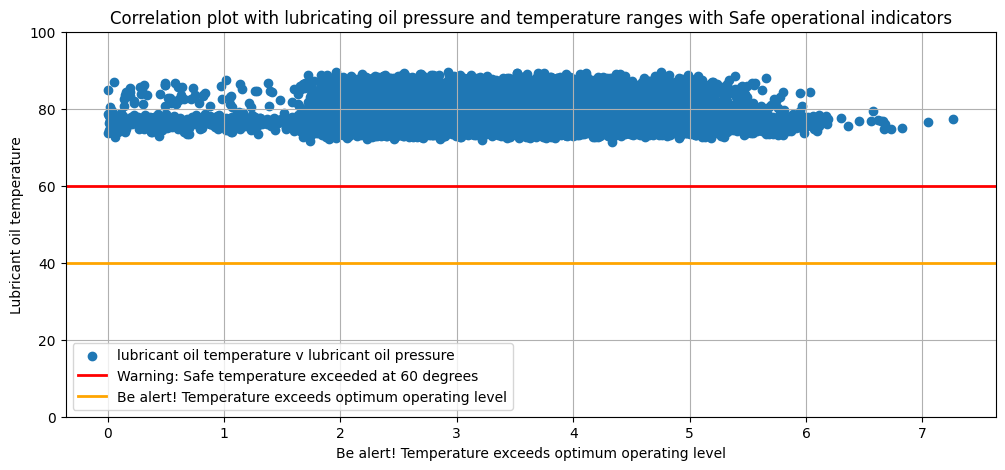

In [71]:
# A closer look at Lubricant Oil Temperature
# Visualise data with scatterplots
plt.figure(figsize=(12, 5))

# Plot the raw data with outliers.
plt.scatter(df['Lub oil pressure'], df['lub oil temp'], label='lubricant oil temperature v lubricant oil pressure')
plt.ylim(0, 100)  # Fix the y-axis scale.
plt.xlabel('Lubricant oil pressure')
plt.ylabel('Lubricant oil temperature')
plt.title('Correlation plot with lubricating oil pressure and temperature ranges with Safe operational indicators')
plt.legend()

# Add the horizontal line at Coolant temp = 60
plt.axhline(y=60, color='red', linestyle='-', linewidth=2, label='Warning: Safe temperature exceeded at 60 degrees')
plt.xlabel('Warning: Safe temperature exceeded at 60 degrees')
plt.legend()

# Add the horizontal line at Coolant temp = 40
plt.axhline(y=40, color='orange', linestyle='-', linewidth=2, label='Be alert! Temperature exceeds optimum operating level') # Include label= to print the plt.xlabel for the axhline
plt.xlabel('Be alert! Temperature exceeds optimum operating level')
plt.legend()

# Set labels and title
plt.grid(True)
plt.show()


nearity

Visualise the data to determine the distribution and extreme values

In [ ]:
# Visualize the data to determine the distribution and extrapolate any extreme values by 4.1.2 identifying the relevant input features- employ preprocessing and feature engineering 4.1.4 data cleaning 4.1.8 perform model training, anomaly detection, post-processing, and refinement. 5.1.2 z-scores 5.1.3 to visualise anomalies and create new columns 5.2.2 wonderful anomaly detection algorithm, and anomaly detection with k-means() - employ preprocessing and feature engineering  4.1.4 data cleaning 4.1.8 perform model training, anomaly detection, post-processing, and refinement. 5.1.2 z-scores 5.1.3 to visualise anomalies and create new columns 5.2.2 wonderful anomaly detection algorithm, and anomaly detection with k-means()

# Pre-process the original dataset
clean = df.drop(0, axis=0)
clean
sns.histplot(data = df, kde = True)
sns.boxplot(data=clean)

# Calculate z-scores
z_scores = clean.apply(zscore)
z_scores

# Set a threshold against which to evaluate the data
threshold = 3 # standard deviations
anomalies = z_scores[(z_scores > threshold) | (z_scores < -threshold)].dropna(how = 'all')
print(anomalies.shape)

# Arrange the plots that visualize the z-scored data
plt.figure(figsize=(12, 5))

# Produce the histogram
plt.subplot(1, 2, 1)
sns.histplot(clean, kde=True, color='blue')
plt.title("Histogram")
plt.xlabel('Value')
plt.ylabel('Frequency')

# Z-score using Engine rpm
plt.subplot(1, 2, 2)
sns.scatterplot(x=z_scores.index, y=z_scores['Engine rpm'] < -threshold, color='g', label='Engine rpm')
sns.scatterplot(x=anomalies.index, y=anomalies['Engine rpm'], color='r')

plt.axhline(3, color='r', linestyle='--')
plt.axhline(-3, color='r', linestyle='--')
plt.title('Scatterplot of z-scores [Engine rpm]')
plt.xlabel([Data])
plt.ylabel("Z-score")

plt.tight_layout()
plt.show()





NameError: name 'zscore' is not defined

In [ ]:
# 4.1.8 Preprocessing and feature engineering to train the model and refine

In [ ]:
# No clear diagnostic, proceeding to anomaly detection. Recommencing with original dataset to run z-scores, k-means and compare the IQR results


Record your thoughts and oberservations

Perform anomaly detection with ML models:
Perform feature scaling to prepare the data for ML algorithms.
Using one-class SVM,
identify possible anomalies
visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
apply different combinations of parameter settings to improve the model's performance
record your insights about the use of this method

In [ ]:
# Feature scaling

Using Isolation Forest,
identify possible anomalies
visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
apply different combinations of parameter settings to improve the model's performanc

In [ ]:

#record your insights about the use of this method.